Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

Read data

In [2]:
merged_data = pd.read_csv("../../data/processed/merged_clean.csv")

Subset data for targeted subgroup

In [3]:
subgroup = merged_data[
    (merged_data["Per_Level_Label"].isin(["B2.1", "B2.2", "C1"])
    ) & (merged_data["Prof_Use_Label"] == "Yes")      
]

In [4]:
subgroup.shape

(198, 31)

Readers data: Focus = "They"

In [6]:
subgroup_readers = subgroup[subgroup["Focus"] == "They"].copy()

In [7]:
subgroup_readers.shape

(78, 31)

Goal_Type

Chi-square test: if Goal_Type  had no relationship with readers' response, what frequencies would we expect by chance?

Observed Frequencies

In [8]:
goal_response_r = pd.crosstab(
    subgroup_readers["Goal_Type"],
    subgroup_readers["Response_Full"]
)

goal_response_r

Response_Full,L1_transfer,L2_other,correct
Goal_Type,,,
goal_frequent,12,6,8
goal_non_frequent,19,1,6
no_goal,12,7,7


Chi-square: Goal_type alone does not strongly organise readers' responses (p-value: 0.)

In [9]:
chi2, p, dof, expected = chi2_contingency(goal_response_r)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 6.9933554817275745
p-value: 0.13623977466868098
Degrees of freedom: 4


Cramér's V test: how strong does the association appear to be?

Cramér's V: ? = small. Goal_Type by itself is not carrying the system for readers.

In [10]:
n = goal_response_r.sum().sum()

k = min(goal_response_r.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.21172907643010677


Residuals

In [11]:
table = Table(goal_response_r)

In [12]:
residuals = table.standardized_resids

print(residuals)

Response_Full      L1_transfer  L2_other       correct
Goal_Type                                             
goal_frequent        -1.126840  0.834523  5.415100e-01
goal_non_frequent     2.253679 -2.294938 -5.415100e-01
no_goal              -1.126840  1.460415  4.809575e-16


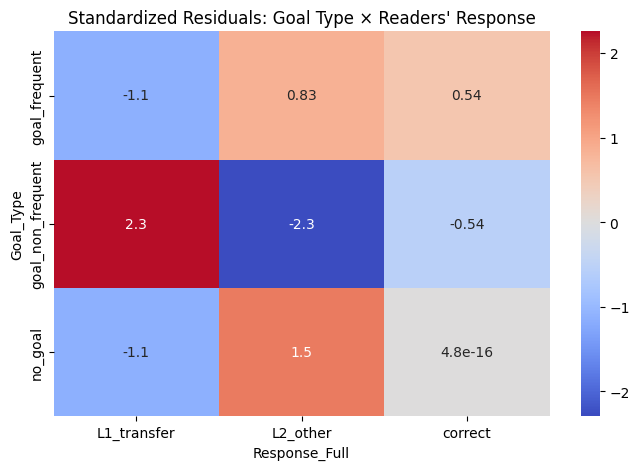

In [13]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Goal Type × Readers' Response")
plt.show()

Agent

Chi-square test: if Agent had no relationship with readers'response, what frequencies would we expect by chance?

Observed frequencies

In [14]:
agent_response_r = pd.crosstab(
    subgroup_readers["Agent"],
    subgroup_readers["Response_Full"]
)

agent_response_r

Response_Full,L1_transfer,L2_other,correct
Agent,,,
0,31,12,11
1,12,2,10


Chi-square: actors' response distributions differ by Agent more than what is expected by chance alone (p_value: 0.0930) 

In [15]:
chi2, p, dof, expected = chi2_contingency(agent_response_r)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 4.750030761658668
p-value: 0.09301305858168149
Degrees of freedom: 2


Cramér's V: 0. ? The overall magnitude of the association is still moderate but higher for readers than for the whole group.

In [16]:
n = agent_response_r.sum().sum()

k = min(agent_response_r.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.24677485746662936


Residuals

In [17]:
table = Table(agent_response_r)

In [18]:
residuals = table.standardized_resids

print(residuals)

Response_Full  L1_transfer  L2_other   correct
Agent                                         
0                 0.607083  1.475242 -1.957072
1                -0.607083 -1.475242  1.957072


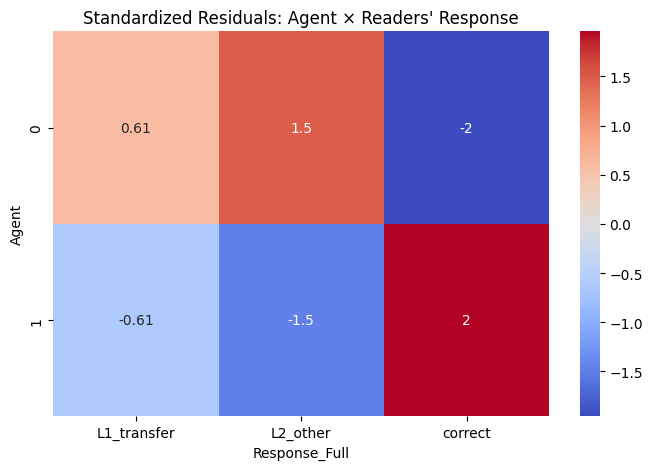

In [19]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Agent × Readers' Response")
plt.show()

Goal_Type X Agent

Chi-square test: if Goal_Type X Agent had no relationship with readers' responses, what frequencies would we expect by chance? 

Observed Frequencies

In [20]:
goal_agent_response_r = pd.crosstab(
    [subgroup_readers["Goal_Type"], subgroup_readers["Agent"]],
    subgroup_readers["Response_Full"]
)

goal_agent_response_r

Response_Full            L1_transfer  L2_other  correct
Goal_Type         Agent                                
goal_frequent     0                7         6        5
                  1                5         0        3
goal_non_frequent 0               14         1        3
                  1                5         0        3
no_goal           0               10         5        3
                  1                2         2        4

Chi-square: ? highest chi-square value for the actors' subser but high p-value suggest that associations exist though they are distributed (p-value: 0.)

In [21]:
chi2, p, dof, expected = chi2_contingency(goal_agent_response_r)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 15.646548541897378
p-value: 0.11020728519844568
Degrees of freedom: 10


Cramér's V: the association is stronger than any of the variable of its own but still moderate (C?).

In [22]:
n = goal_agent_response_r.sum().sum()

k = min(goal_agent_response_r.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Cramér's V:", cramers_v)

Cramér's V: 0.3166992075915028


Residuals

In [23]:
table = Table(goal_agent_response_r)

In [24]:
residuals = table.standardized_resids

print(residuals)

Response_Full            L1_transfer  L2_other   correct
Goal_Type         Agent                                 
goal_frequent     0        -1.506674  1.766066  0.130658
                  1         0.272236 -1.031232  0.608614
goal_non_frequent 0         2.263419 -1.653523 -1.083697
                  1         0.272236 -1.031232  0.608614
no_goal           0         0.109080  1.082148 -1.083697
                  1        -1.763059  0.457391  1.581530


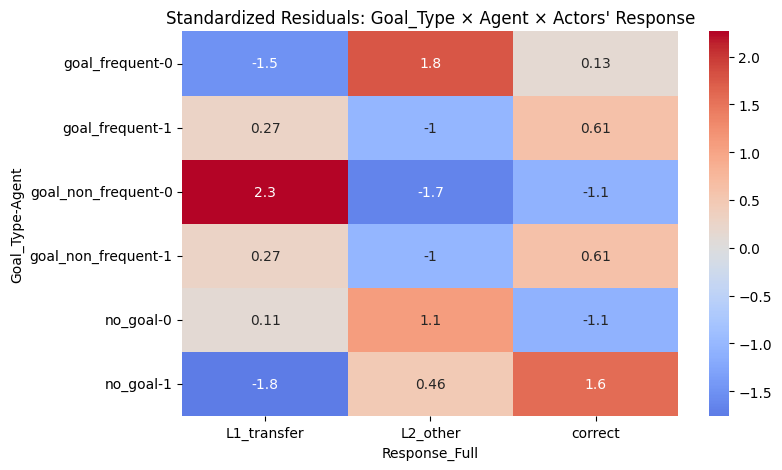

In [25]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals, 
    annot= True,
    cmap= "coolwarm",
    center = 0
)

plt.title("Standardized Residuals: Goal_Type × Agent × Actors' Response")
plt.show()